### Libraries

In [1]:
%%capture

# To install packages if not installed
%pip install pandas
%pip install seaborn
%pip install statsmodels
%pip install matplotlib
%pip install numpy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os

pd.set_option('display.width', 500)

In [3]:
df = pd.read_excel("data/Data_FE.xlsx", sheet_name="25 Size and BEME portfolios")
df.head()

,Unnamed: 0,Average,Value,Weighted,Returns,--,Monthly,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,Size,Small,Small,Small,Small,Small,2,2.00,2.00,2.00,...,4,4.00,4.00,4.00,4,Big,Big,Big,Big,Big
1,BE/ME,Low,2,3,4,High,Low,2.00,3.00,4.00,...,Low,2.00,3.00,4.00,High,Low,2,3,4,High
2,193601,26.94,15.49,21.82,14.56,33.28,16.43,12.49,9.49,10.27,...,2.13,6.87,8.92,8.35,6.17,2.55,6.36,8.62,14.84,16.29
3,193602,9.46,12.78,6.77,10.02,9,1.7,6.71,5.61,8.92,...,2.59,4.04,6.14,4.80,8.43,1.88,1.18,3.99,3.38,3.75
4,193603,9.46,1.38,5.56,3.01,1.24,-0.37,1.35,3.33,-1.11,...,-0.46,-0.40,3.19,1.52,-4.36,3.58,1.27,-1.82,1.26,-3.56


In [4]:
# Set rows 1 and 2 as MultiIndex header
df.columns = pd.MultiIndex.from_arrays([df.iloc[0], df.iloc[1]])
df = df.iloc[2:].reset_index(drop=True)

# Convert Date column to Year-Month
date_col = df.columns[0]

df[date_col] = pd.to_datetime(df[date_col].astype(int), format="%Y%m")

df = df.set_index(df.columns[0]) 
df = df.apply(pd.to_numeric)

df.head()

0              Small                                  2                              ...     4                              Big                          
1                Low      2      3      4   High    Low      2      3      4   High  ...   Low     2      3      4   High   Low     2     3      4   High
(Size, BE/ME)                                                                        ...                                                                 
1936-01-01     26.94  15.49  21.82  14.56  33.28  16.43  12.49   9.49  10.27  26.81  ...  2.13  6.87   8.92   8.35   6.17  2.55  6.36  8.62  14.84  16.29
1936-02-01      9.46  12.78   6.77  10.02   9.00   1.70   6.71   5.61   8.92   3.87  ...  2.59  4.04   6.14   4.80   8.43  1.88  1.18  3.99   3.38   3.75
1936-03-01      9.46   1.38   5.56   3.01   1.24  -0.37   1.35   3.33  -1.11   1.25  ... -0.46 -0.40   3.19   1.52  -4.36  3.58  1.27 -1.82   1.26  -3.56
1936-04-01    -28.60 -29.05 -12.37 -14.03 -21.72 -19.41 -13.35 -15.93 -16.43 -17.69  ... -8.31 -9.00 -11.90 -12.09 -12.46 -6.17 -8.26 -7.05 -10.57  -8.00
1936-05-01      1.81   8.62   1.89  10.60   5.90   5.21   4.59   7.57   5.84   6.97  ...  5.12  1.79   4.54   5.98   8.18  4.78  5.20  4.71   6.25   8.39

[5 rows x 25 columns]

### Fama-French Factors Data

In [5]:
FF_factors = pd.read_excel("data/Data_FE.xlsx", sheet_name="Fama-French factors")

# Convert Date column to Year-Month
date_col = FF_factors.columns[0] 

FF_factors[date_col] = pd.to_datetime(FF_factors[date_col].astype(int), format="%Y%m")
FF_factors = FF_factors.set_index(FF_factors.columns[0]) 
FF_factors = FF_factors.apply(pd.to_numeric)

FF_factors.head()

,Mkt-RF,SMB,HML,RF
Date,,,,
1936-01-01,6.60,6.43,10.09,0.01
1936-02-01,2.56,0.77,3.98,0.01
1936-03-01,0.92,1.10,-2.23,0.02
1936-04-01,-8.07,-6.81,-2.18,0.02
1936-05-01,5.01,0.81,2.69,0.02


### Macroeconomic Factors Data

In [6]:
macro_factors = pd.read_excel("data/Data_FE.xlsx", sheet_name="Macroeconomic factors")

# Convert Date column to Year-Month
date_col = macro_factors.columns[0] 

macro_factors[date_col] = pd.to_datetime(macro_factors[date_col].astype(int), format="%Y%m")
macro_factors = macro_factors.set_index(macro_factors.columns[0]) 
macro_factors = macro_factors.apply(pd.to_numeric)

macro_factors.head()

,Div_growth,DEF = LT Corp. - LT govt.,TERM = ST govt.-LT govt.
Date,,,
1936-01-01,0.001990,0.002660,0.005395
1936-02-01,0.003113,-0.002690,0.007990
1936-03-01,0.003308,-0.002406,0.010458
1936-04-01,0.001250,-0.000924,0.003359
1936-05-01,0.004499,-0.000049,0.003887


### Excess Returns

In [7]:
excess_returns = df.copy()

FF_factors = FF_factors.reindex(excess_returns.index)

excess_returns = excess_returns.sub(FF_factors["RF"], axis=0)
excess_returns.head()

0              Small                                  2                              ...     4                              Big                          
1                Low      2      3      4   High    Low      2      3      4   High  ...   Low     2      3      4   High   Low     2     3      4   High
(Size, BE/ME)                                                                        ...                                                                 
1936-01-01     26.93  15.48  21.81  14.55  33.27  16.42  12.48   9.48  10.26  26.80  ...  2.12  6.86   8.91   8.34   6.16  2.54  6.35  8.61  14.83  16.28
1936-02-01      9.45  12.77   6.76  10.01   8.99   1.69   6.70   5.60   8.91   3.86  ...  2.58  4.03   6.13   4.79   8.42  1.87  1.17  3.98   3.37   3.74
1936-03-01      9.44   1.36   5.54   2.99   1.22  -0.39   1.33   3.31  -1.13   1.23  ... -0.48 -0.42   3.17   1.50  -4.38  3.56  1.25 -1.84   1.24  -3.58
1936-04-01    -28.62 -29.07 -12.39 -14.05 -21.74 -19.43 -13.37 -15.95 -16.45 -17.71  ... -8.33 -9.02 -11.92 -12.11 -12.48 -6.19 -8.28 -7.07 -10.59  -8.02
1936-05-01      1.79   8.60   1.87  10.58   5.88   5.19   4.57   7.55   5.82   6.95  ...  5.10  1.77   4.52   5.96   8.16  4.76  5.18  4.69   6.23   8.37

[5 rows x 25 columns]

---

## Fama-Mechbath Linear Regression
Function to run Fama-Macbeth linear regression, the implementation of the function is to avoid repetation of code for different data sets. The Inputs should be columns (dataframe type) of target varaibles and explanatory variable 

In [8]:
def Fama_Macbeth(independent_df, target_df):

    # time-series regressions
    X = sm.add_constant(independent_df)

    betas = []
    r_squa = []
    const = []
    cross_rsqua = []

    for j in range(len(target_df.columns)):
        y = target_df.iloc[:, j]
        model = sm.OLS(y, X).fit()

        r_squa.append(model.rsquared)
        params = model.params

        const.append(params.iloc[0])
        betas.append(params.iloc[1:])       

    betas = pd.DataFrame(betas, index=target_df.columns)
    betas.columns = independent_df.columns

    # cross-sectional regressions
    gammas = []

    for t in range(len(target_df)):
        # 25 portfolio returns at time t
        y_t = target_df.iloc[t, :]          
        # betas are fixed across time
        X_cs = sm.add_constant(betas)       

        model_cs = sm.OLS(y_t, X_cs).fit()
        gammas.append(model_cs.params)
        cross_rsqua.append(model_cs.rsquared)

    gammas = pd.DataFrame(gammas, index=target_df.index)

    # risk premia estimates
    gamma_mean = gammas.mean()
    gamma_std = gammas.std()

    T = len(gammas)

    gamma_se = gamma_std / np.sqrt(T)
    gamma_t = gamma_mean / gamma_se

    results = pd.DataFrame({'Mean Gamma': gamma_mean, 'Std Dev': gamma_std, 'Std Error': gamma_se, 't-stat': gamma_t})

    return results, betas, gammas, r_squa, cross_rsqua

---

## Fama-French 3 Factor Model

$$R(t)-RF(t)=a+b[RM(t)-RF(t)]+sSMB(t)+hHML(t)+c(t)$$

In [9]:
X = FF_factors[["Mkt-RF", "SMB", "HML"]]
Y = excess_returns.copy()

FF_model_results, FF_betas, FF_gammas, FF_r_squa, FF_cross_rsqua = Fama_Macbeth(X, Y)
FF_model_results.head()

,Mean Gamma,Std Dev,Std Error,t-stat
const,1.701787,8.350195,0.283098,6.011296
Mkt-RF,-1.020456,9.243081,0.313370,-3.256397
SMB,0.112178,3.105784,0.105296,1.065361
HML,0.447678,2.981375,0.101078,4.429034


---

## Macroeconomics Factor Model

In [10]:
X = macro_factors[["Div_growth", "DEF = LT Corp. - LT govt.", "TERM = ST govt.-LT govt."]]
Y = excess_returns.copy()

macro_model_results, macro_betas, macro_gammas, macro_r_squa, macro_cross_rsqua = Fama_Macbeth(X, Y)
macro_model_results.head()

,Mean Gamma,Std Dev,Std Error,t-stat
const,-0.464905,8.904348,0.301886,-1.540003
Div_growth,-0.000712,0.012236,0.000415,-1.715868
DEF = LT Corp. - LT govt.,0.002327,0.072539,0.002459,0.946242
TERM = ST govt.-LT govt.,0.016285,0.186732,0.006331,2.572388


---

## In-sample Principle Component Factors

In [11]:
# covariance matrix of excess returns
cova_matrix = excess_returns.cov()

# Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cova_matrix)

# eigh returns in ASCENDING order — reverse to get largest first
idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]    # 25 × 25, columns are eigenvectors

# extracting 3 largest eigenvectors, the factor weights is 25 x 3
W = eigenvectors[:, :3]

# factor time-series (T x 3)
F = excess_returns.values @ W 

in_sample_factors_df = pd.DataFrame(F, index=excess_returns.index, columns=['In-sample-PC1', 'In-sample-PC2', 'In-sample-PC3'])

in_sample_factors_df.head()

,In-sample-PC1,In-sample-PC2,In-sample-PC3
"(Size, BE/ME)",,,
1936-01-01,68.001015,-8.412505,20.995417
1936-02-01,27.493475,-1.839059,7.573483
1936-03-01,8.509176,-6.095500,-1.366945
1936-04-01,-70.252885,11.293506,-4.734255
1936-05-01,27.800508,7.462751,4.330489


### Linear regression for In-sample PC factors

In [12]:
X = in_sample_factors_df[["In-sample-PC1", "In-sample-PC2", "In-sample-PC3"]]
Y = excess_returns.copy()

insample_model_results, insample_betas, insample_gammas, insample_r_squa, insample_cross_rsqua = Fama_Macbeth(X, Y)
insample_model_results.copy()

,Mean Gamma,Std Dev,Std Error,t-stat
const,0.781046,7.067361,0.239606,3.259712
In-sample-PC1,0.393877,44.707274,1.515719,0.259861
In-sample-PC2,0.261904,8.848362,0.299988,0.873050
In-sample-PC3,0.843901,6.396585,0.216865,3.891376


---

## Out-sample principle Component Factors

### Even and Odd Monthly Returns dataframes

In [13]:
# making odd monthly return and even monthly returns dataframe
odd_returns_df = excess_returns.copy()
odd_returns_df = odd_returns_df.iloc[0::2]

even_returns_df = excess_returns.copy()
even_returns_df = even_returns_df.iloc[1::2]

# covariance matrix
cova_matrix_even = even_returns_df.cov()
cova_matrix_odd = odd_returns_df.cov()

In [14]:
# Eigendecomposition for even
eigenvalues_even, eigenvectors_even = np.linalg.eigh(cova_matrix_even)

# eigh returns in ascending order — reverse to get largest first
idx = np.argsort(eigenvalues_even)[::-1]
eigenvalues_even  = eigenvalues_even[idx]
eigenvectors_even = eigenvectors_even[:, idx]    # 25 × 25, columns are eigenvectors

# extracting 3 largest eigenvectors, the factor weights is 25 x 3
W_even = eigenvectors_even[:, :3]

# Eigendecomposition for odd
eigenvalues_odd, eigenvectors_odd = np.linalg.eigh(cova_matrix_odd)

# eigh returns in ascending order — reverse to get largest first
idx = np.argsort(eigenvalues_odd)[::-1]
eigenvalues_odd  = eigenvalues_odd[idx]
eigenvectors_odd = eigenvectors_odd[:, idx]    # 25 × 25, columns are eigenvectors

# extracting 3 largest eigenvectors, the factor weights is 25 x 3
W_odd = eigenvectors_odd[:, :3]

# factor time-series (T x 25)
F_even = even_returns_df.values @ W_odd
F_odd = odd_returns_df.values @ W_even

# Create empty dataframe with full index
out_sample_factors_df = pd.DataFrame(index=df.index, columns=['Out-sample-PC1', 'Out-sample-PC2', 'Out-sample-PC3'], dtype=float)

# Assign values to correct timestamps
out_sample_factors_df.loc[even_returns_df.index] = F_even
out_sample_factors_df.loc[odd_returns_df.index]  = F_odd

out_sample_factors_df.head()

,Out-sample-PC1,Out-sample-PC2,Out-sample-PC3
"(Size, BE/ME)",,,
1936-01-01,66.913245,3.574769,22.453430
1936-02-01,27.629565,-4.414048,4.949131
1936-03-01,8.632598,6.225375,0.017546
1936-04-01,-70.228621,10.833031,3.799454
1936-05-01,27.621213,-8.026760,4.728671


### Linear regression for Out-sample PC factors

In [15]:
X = out_sample_factors_df[["Out-sample-PC1", "Out-sample-PC2", "Out-sample-PC3"]]
Y = excess_returns.copy()

outsample_model_results, outsample_betas, outsample_gammas, outsample_r_squa, outsample_cross_rsqua = Fama_Macbeth(X, Y)
outsample_model_results.copy()

,Mean Gamma,Std Dev,Std Error,t-stat
const,0.860121,6.570503,0.222761,3.861183
Out-sample-PC1,-0.008894,42.787171,1.450621,-0.006131
Out-sample-PC2,-1.959988,26.407040,0.895283,-2.189240
Out-sample-PC3,0.351194,10.757888,0.364727,0.962896


---

## Comparing the Models

### Constants

In [16]:
constants_df = pd.DataFrame({
    'Fama-French Factors': FF_gammas.iloc[:, 0],
    'Macroeconomic Factors': macro_gammas.iloc[:, 0],
    "In-sample Model": insample_gammas.iloc[:, 0],
    "Out-sample Model": outsample_gammas.iloc[:, 0]
})

constants_df.describe()

,Fama-French Factors,Macroeconomic Factors,In-sample Model,Out-sample Model
count,870.000000,870.000000,870.000000,870.000000
mean,1.701787,-0.464905,0.781046,0.860121
std,8.350195,8.904348,7.067361,6.570503
min,-35.885009,-45.190330,-33.198617,-52.985758
25%,-2.798892,-5.320693,-3.387358,-2.087628
50%,1.537422,-0.179215,0.601352,0.947277
75%,6.336176,4.978030,5.165833,4.480628
max,39.537538,36.180997,32.303541,46.925879


### $R^{2}$ Values

In [17]:
rsquare_df = pd.DataFrame({
    'Fama-French Factors': FF_r_squa,
    'Macroeconomic Factors': macro_r_squa,
    'In-sample Model': insample_r_squa,
    'Out-sample Model': outsample_r_squa
})
display(rsquare_df.describe())

cross_rsquare_df = pd.DataFrame({
    'Fama-French Factors': FF_cross_rsqua,
    'Macroeconomic Factors': macro_cross_rsqua,
    'In-sample Model': insample_cross_rsqua,
    'Out-sample Model': outsample_cross_rsqua
})
cross_rsquare_df.describe()


,Fama-French Factors,Macroeconomic Factors,In-sample Model,Out-sample Model
count,25.000000,25.000000,25.000000,25.000000
mean,0.911570,0.067166,0.925203,0.874552
std,0.030558,0.013556,0.030476,0.074900
min,0.826192,0.039975,0.843374,0.684355
25%,0.900677,0.057751,0.920025,0.855043
50%,0.912003,0.065687,0.936729,0.898023
75%,0.937168,0.077926,0.943860,0.927730
max,0.954548,0.092162,0.956475,0.947240


,Fama-French Factors,Macroeconomic Factors,In-sample Model,Out-sample Model
count,870.000000,870.000000,870.000000,870.000000
mean,0.492314,0.382995,0.487216,0.448145
std,0.234076,0.196228,0.232151,0.234908
min,0.002560,0.002738,0.007613,0.012430
25%,0.311378,0.228746,0.307337,0.246860
50%,0.503961,0.374445,0.509131,0.444494
75%,0.683951,0.532095,0.673045,0.642195
max,0.948335,0.924895,0.940231,0.950472


In [18]:
print(f"Fama-French Factors: {np.mean(FF_r_squa)}")
print(f"Macroeconomic Factors: {np.mean(macro_r_squa)}")
print(f"In-sample Model: {np.mean(insample_r_squa)}")
print(f"Out-sample Model: {np.mean(outsample_r_squa)}")

Fama-French Factors: 0.9115701999594907
Macroeconomic Factors: 0.06716555874907165
In-sample Model: 0.9252032720890996
Out-sample Model: 0.8745521038578993


----

## Save Data to CSV

In [19]:
os.makedirs("asset_pricing_results", exist_ok=True)

FF_betas.to_csv("asset_pricing_results/FF_betas.csv", encoding="utf-8-sig")
FF_model_results.to_csv("asset_pricing_results/FF_model_results.csv", encoding="utf-8-sig")
pd.Series(FF_r_squa).to_csv("asset_pricing_results/FF_r_squa.csv", encoding="utf-8-sig", header=["r_squared"])

macro_betas.to_csv("asset_pricing_results/macro_betas.csv", encoding="utf-8-sig")
macro_model_results.to_csv("asset_pricing_results/macro_model_results.csv", encoding="utf-8-sig")
pd.Series(macro_r_squa).to_csv("asset_pricing_results/macro_r_squa.csv", encoding="utf-8-sig", header=["r_squared"])

insample_betas.to_csv("asset_pricing_results/insample_betas.csv", encoding="utf-8-sig")
insample_model_results.to_csv("asset_pricing_results/insample_model_results.csv", encoding="utf-8-sig")
pd.Series(insample_r_squa).to_csv("asset_pricing_results/insample_r_squa.csv", encoding="utf-8-sig", header=["r_squared"])

outsample_betas.to_csv("asset_pricing_results/outsample_betas.csv", encoding="utf-8-sig")
outsample_model_results.to_csv("asset_pricing_results/outsample_model_results.csv", encoding="utf-8-sig")
pd.Series(outsample_r_squa).to_csv("asset_pricing_results/outsample_r_squa.csv", encoding="utf-8-sig", header=["r_squared"])

---

## Simplified Fama-Macbeth Process

In [20]:
def Fama_Macbeth_gamma(independent_df, target_df):

    # time-series regressions to estimate betas
    X = sm.add_constant(independent_df)

    betas = []
    r_squa = []
    alphas = []

    for j in range(len(target_df.columns)):
        y = target_df.iloc[:, j]
        model = sm.OLS(y, X).fit()

        r_squa.append(model.rsquared)
        params = model.params

        alphas.append(params.iloc[0])     
        betas.append(params.iloc[1:])      

    betas = pd.DataFrame(betas, index=target_df.columns)
    betas.columns = independent_df.columns

    # cross-sectional regression to estimate gamma
    avg_returns = target_df.mean()

    X_cs = sm.add_constant(betas)
    gamma_model = sm.OLS(avg_returns, X_cs).fit()

    gamma = gamma_model.params

    # standard errors (optional)
    gamma_se = gamma_model.bse
    gamma_t = gamma_model.tvalues

    results = pd.DataFrame({'Gamma': gamma, 'Std Error': gamma_se, 't-stat': gamma_t})

    return results, betas, alphas, r_squa

---

## Comparision Between Original Fama Macbeth and Simplified

Gamma Estimate
        Simplified Fama MacBeth  Original Fama MacBeth  |Delta Gamma|  % Diff
const                  1.701787               1.701787   0.000000e+00     0.0
Mkt-RF                -1.020456              -1.020456   4.440892e-16     0.0
SMB                    0.112178               0.112178   2.775558e-17     0.0
HML                    0.447678               0.447678   1.110223e-16     0.0
Standard Error & T-Stats
        SE Simplified  SE Original  t-Stat Simplified  t-Stat Original  SE Ratio (Simp/Orig)  t-Stat Ratio (Simp/Orig)
const        0.382417     0.283098           4.450084         6.011296                1.3508                    0.7403
Mkt-RF       0.372218     0.313370          -2.741556        -3.256397                1.1878                    0.8419
SMB          0.049562     0.105296           2.263386         1.065361                0.4707                    2.1245
HML          0.062854     0.101078           7.122497         4.429034                0.6218  

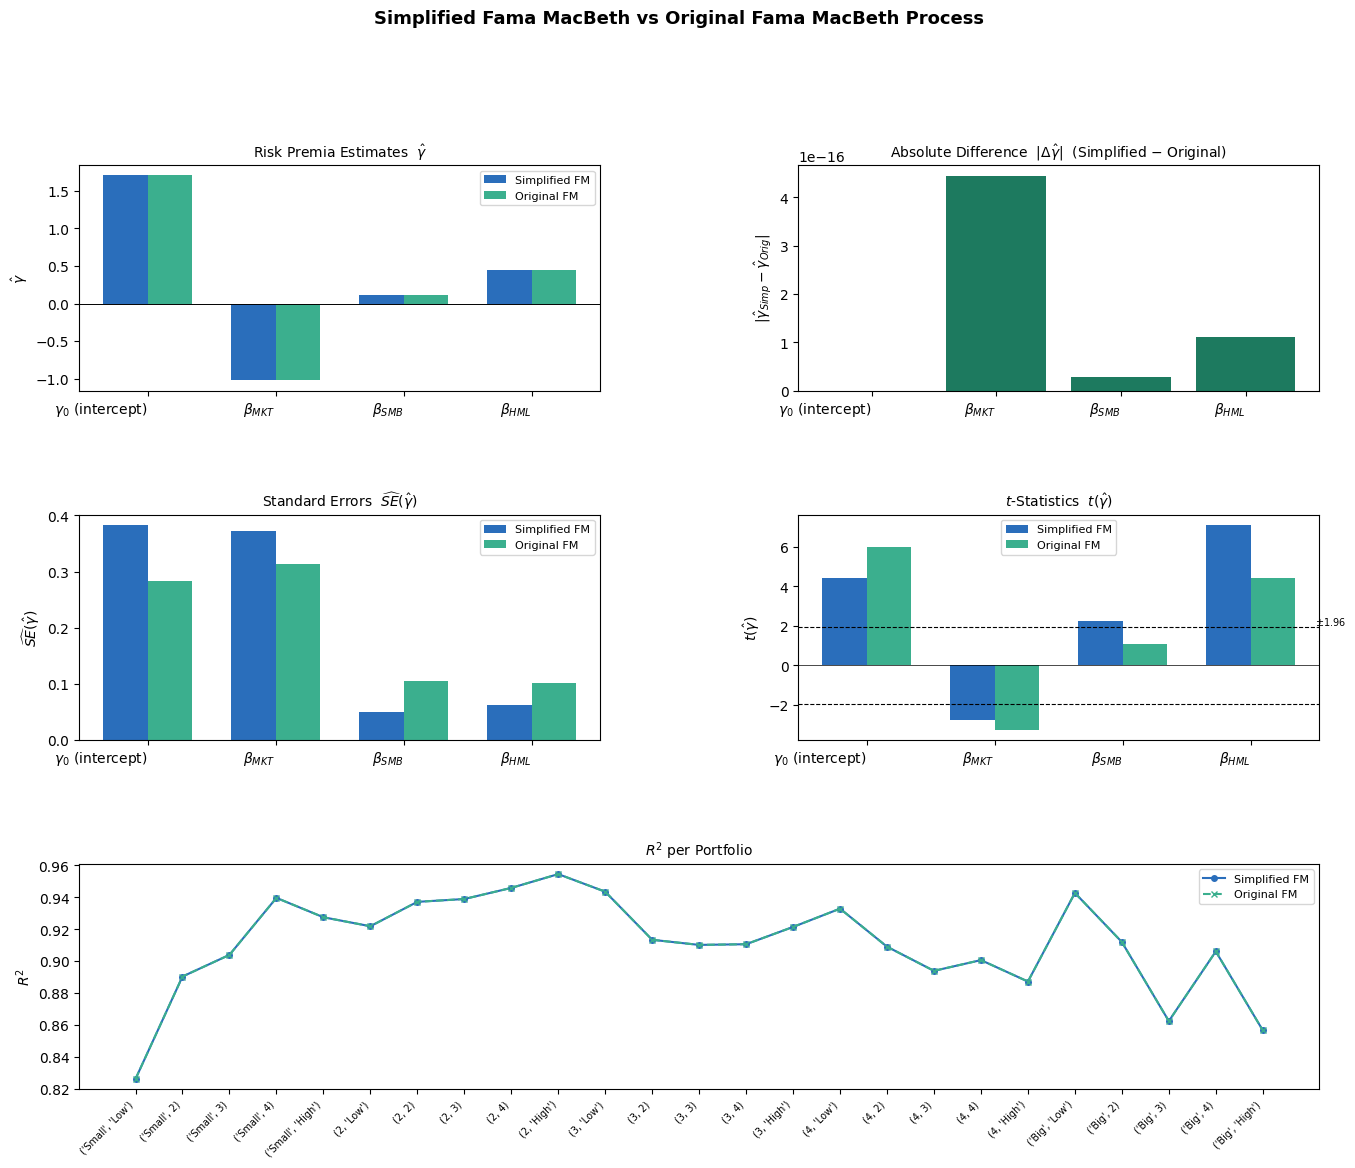

In [21]:
import matplotlib.gridspec as gridspec

X = FF_factors[["Mkt-RF", "SMB", "HML"]]
Y = excess_returns.copy()

# simplified is the one-shot cross-sectional regression taking average returns,
# original rolls through each time period separately
res_gamma, betas_gamma, alphas_gamma, rsq_gamma = Fama_Macbeth_gamma(X, Y)
res_fm, betas_fm, gammas_fm, rsq_fm, _ = Fama_Macbeth(X, Y)

# Gamma Estimate

gamma_compare = pd.DataFrame({
    'Simplified Fama MacBeth' : res_gamma['Gamma'],
    'Original Fama MacBeth' : res_fm['Mean Gamma'],
})
gamma_compare['|Delta Gamma|'] = (gamma_compare['Simplified Fama MacBeth'] - gamma_compare['Original Fama MacBeth']).abs()
gamma_compare['% Diff'] = (gamma_compare['|Delta Gamma|'] / gamma_compare['Original Fama MacBeth'].abs() * 100).round(4)

print("Gamma Estimate")
print(gamma_compare.to_string())

# Standard Errors & T-Statistic

se_compare = pd.DataFrame({
    'SE Simplified': res_gamma['Std Error'],
    'SE Original' : res_fm['Std Error'],
    't-Stat Simplified': res_gamma['t-stat'],
    't-Stat Original' : res_fm['t-stat'],
})
se_compare['SE Ratio (Simp/Orig)'] = (se_compare['SE Simplified'] / se_compare['SE Original']).round(4)
se_compare['t-Stat Ratio (Simp/Orig)'] = (se_compare['t-Stat Simplified'] / se_compare['t-Stat Original']).round(4)

print("Standard Error & T-Stats")
print(se_compare.to_string())

# Betas

beta_diff = (betas_gamma - betas_fm).abs()

print("Delta Beta")
print(f"Max |Delta Beta|: {beta_diff.values.max():.2e}")
print(f"Mean |Delta Beta|: {beta_diff.values.mean():.2e}")
print(f"All equal: {np.allclose(betas_gamma.values, betas_fm.values)}")

# R-Squared

rsq_compare = pd.DataFrame({
    'R-Squared Simplified': rsq_gamma,
    'R-Squared Original': rsq_fm,
}, index=Y.columns)
rsq_compare['|Delta R-Squared|'] = (rsq_compare['R-Squared Simplified'] - rsq_compare['R-Squared Original']).abs()

print("R-Squared Difference")
print(f"Max |Delta R-Squared|: {rsq_compare['|Delta R-Squared|'].max():.2e}")
print(f"Mean |Delta R-Squared|: {rsq_compare['|Delta R-Squared|'].mean():.2e}")
print(f"All equal: {np.allclose(rsq_compare['R-Squared Simplified'], rsq_compare['R-Squared Original'])}")

# Plots
# color scheme for plots
sim_fama = '#2A6EBB'
orgi_fama = '#3BAF8E'
diff_color = '#1D7A5F'

factor_labels = {
    'const' : r'$\gamma_0$ (intercept)',
    'Mkt-RF' : r'$\beta_{MKT}$',
    'SMB' : r'$\beta_{SMB}$',
    'HML' : r'$\beta_{HML}$',
}
factors = gamma_compare.index.tolist()
tick_labels = [factor_labels.get(f, f) for f in factors]

x = np.arange(len(factors))
w = 0.35

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.38)

# Gamma estimates plots
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(x - w/2, gamma_compare['Simplified Fama MacBeth'], w, label='Simplified FM', color=sim_fama)
ax1.bar(x + w/2, gamma_compare['Original Fama MacBeth'],   w, label='Original FM',   color=orgi_fama)
ax1.set_xticks(x)
ax1.set_xticklabels(tick_labels, ha='right', fontsize=10)
ax1.axhline(0, color='black', lw=0.7)
ax1.set_title(r'Risk Premia Estimates  $\hat{\gamma}$', fontsize=10)
ax1.set_ylabel(r'$\hat{\gamma}$', fontsize=10)
ax1.legend(fontsize=8)

# Gamma difference between the two methods
# any non-trivial bar here would be surprising given both estimate the same underlying quantity
# small numerical differences are fine
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(x, gamma_compare['|Delta Gamma|'], color=diff_color)
ax2.set_xticks(x)
ax2.set_xticklabels(tick_labels, ha='right', fontsize=10)
ax2.set_title(r'Absolute Difference  $|\Delta\hat{\gamma}|$  (Simplified $-$ Original)', fontsize=10)
ax2.set_ylabel(r'$|\hat{\gamma}_{Simp} - \hat{\gamma}_{Orig}|$', fontsize=10)

# Standard errors of Gamma
ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(x - w/2, se_compare['SE Simplified'], w, label='Simplified FM', color=sim_fama)
ax3.bar(x + w/2, se_compare['SE Original'],   w, label='Original FM',   color=orgi_fama)
ax3.set_xticks(x)
ax3.set_xticklabels(tick_labels, ha='right', fontsize=10)
ax3.set_title(r'Standard Errors  $\widehat{SE}(\hat{\gamma})$', fontsize=10)
ax3.set_ylabel(r'$\widehat{SE}(\hat{\gamma})$', fontsize=10)
ax3.legend(fontsize=8)

# t-statistics of Gamma
# dashed lines is at 5% significance
ax4 = fig.add_subplot(gs[1, 1])
ax4.bar(x - w/2, se_compare['t-Stat Simplified'], w, label='Simplified FM', color=sim_fama)
ax4.bar(x + w/2, se_compare['t-Stat Original'],   w, label='Original FM',   color=orgi_fama)
ax4.set_xticks(x)
ax4.set_xticklabels(tick_labels, ha='right', fontsize=10)
ax4.axhline( 1.96, color='black', lw=0.8, ls='--')
ax4.axhline(-1.96, color='black', lw=0.8, ls='--')
ax4.axhline(0, color='black', lw=0.5)
ax4.text(len(x) - 0.5,  2.05, r'$\pm 1.96$', fontsize=7, color='black')
ax4.set_title(r'$t$-Statistics  $t(\hat{\gamma})$', fontsize=10)
ax4.set_ylabel(r'$t(\hat{\gamma})$', fontsize=10)
ax4.legend(fontsize=8)

# R-squared per portfolio across all 25 portfolios
ax5 = fig.add_subplot(gs[2, :])
port_idx = np.arange(len(rsq_compare))
ax5.plot(port_idx, rsq_compare['R-Squared Simplified'], 'o-', label='Simplified FM', color=sim_fama, ms=4)
ax5.plot(port_idx, rsq_compare['R-Squared Original'], 'x--', label='Original FM', color=orgi_fama, ms=4)
ax5.set_xticks(port_idx)
ax5.set_xticklabels(rsq_compare.index, rotation=45, ha='right', fontsize=7)
ax5.set_title(r'$R^2$ per Portfolio', fontsize=10)
ax5.set_ylabel(r'$R^2$', fontsize=10)
ax5.legend(fontsize=8)

plt.suptitle(r'Simplified Fama MacBeth vs Original Fama MacBeth Process',
    fontsize=13, fontweight='bold', y=1.01
)

plt.show()

---

## Statistics Checks on the Data

### Multicolinearity Test (Variance Inflation Factor)

In [22]:
X = FF_factors[["Mkt-RF", "SMB", "HML"]]

FF_vif_data = pd.DataFrame()
FF_vif_data["feature"] = X.columns

FF_vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

print(FF_vif_data)

  feature       VIF
0  Mkt-RF  1.147146
1     SMB  1.143665
2     HML  1.003285


In [23]:
X = macro_factors[["Div_growth", "DEF = LT Corp. - LT govt.", "TERM = ST govt.-LT govt."]]

macro_vif_data = pd.DataFrame()
macro_vif_data["feature"] = X.columns

macro_vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

print(macro_vif_data)


                     feature       VIF
0                 Div_growth  1.007206
1  DEF = LT Corp. - LT govt.  1.266019
2   TERM = ST govt.-LT govt.  1.270066


In [24]:
X = in_sample_factors_df[["In-sample-PC1", "In-sample-PC2", "In-sample-PC3"]]

insample_vif_data = pd.DataFrame()
insample_vif_data["feature"] = X.columns

insample_vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

print(insample_vif_data)

         feature       VIF
0  In-sample-PC1  1.000565
1  In-sample-PC2  1.000528
2  In-sample-PC3  1.000328


In [25]:
X = out_sample_factors_df[["Out-sample-PC1", "Out-sample-PC2", "Out-sample-PC3"]]

outsample_vif_data = pd.DataFrame()
outsample_vif_data["feature"] = X.columns

outsample_vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

print(outsample_vif_data)

          feature       VIF
0  Out-sample-PC1  1.004437
1  Out-sample-PC2  1.023456
2  Out-sample-PC3  1.027939


---
##### Author: Hema Srikar Ankem

No form of AI is used in creating this Jupyter notebook